# From Chat to Code

---

You have already used ChatGPT in the browser. You typed something, pressed Enter, and got an answer back.

This notebook shows you that **exactly the same thing happens when you write Python code** — you are just doing it yourself instead of through a website.

No prior coding experience needed. Every line is explained.

---

### The one idea to hold onto

```
┌──────────────────────┐            ┌──────────────────────┐
│   ChatGPT website    │            │   Your Python code   │
│                      │            │                      │
│  Type a message      │  same      │  Write a string      │
│  Press Enter         │ ─────────▶ │  Call the API        │
│  Read the reply      │  thing     │  Print the reply     │
└──────────────────────┘            └──────────────────────┘
         Both send your message to the same OpenAI servers.
         The website is just a prettier way to do it.
```

---

### What you will be able to do by the end

- Make your first API call from Python
- Understand what an API key is and why it matters
- Send a message and read the reply in code
- Control the model's persona using instructions
- Build a reusable function
- Run a multi-turn conversation
- See how tokens and costs work

---
## Part 1 — Getting Set Up

### What is an API key?

When you log into ChatGPT, the website uses your email and password to identify you.

When **your code** talks to OpenAI, it uses an **API key** instead — a long string of characters that acts as your password for the API. Without it, OpenAI does not know who is making the request or who to charge.

> ⚠️ **Treat your API key like a password.** Never paste it into a shared notebook. Never post it online. If you accidentally expose it, go to platform.openai.com and delete it immediately.

Get your key here: **platform.openai.com → API keys → Create new secret key**

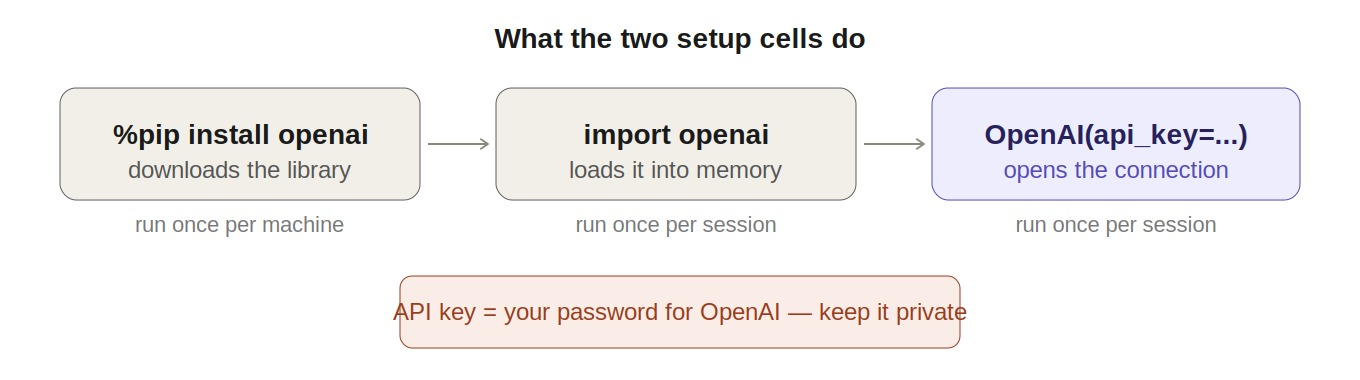

In [ ]:
# This downloads and installs the OpenAI library.
# A "library" is a package of ready-made code someone else wrote
# so you do not have to build everything from scratch.
# --quiet just hides the long installation log.

%pip install openai --quiet
print("✅ Library installed")

In [ ]:
# This loads the library into memory so we can use it.
import openai

# ── YOUR API KEY ──────────────────────────────────────────────
# Replace the text between the quotes with your actual key.
# Your key starts with "sk-"

API_KEY = "sk-..."   # ← paste your key here

# This creates a "client" object — think of it as opening
# a connection to the OpenAI service, like loading a new browser tab.
client = openai.OpenAI(api_key=API_KEY)

print("✅ Connected to OpenAI")

> 💡 **Safer option — Colab Secrets:** Instead of pasting your key directly into the notebook (where someone could see it), use Colab's built-in secret storage.
>
> Click the 🔑 icon in the left panel → add a secret called `OPENAI_API_KEY` → then replace the `API_KEY = "sk-..."` line above with:
> ```python
> from google.colab import userdata
> API_KEY = userdata.get("OPENAI_API_KEY")
> ```
> Your key stays hidden even if you share the notebook.

---
## Part 2 — Your First Message

### ChatGPT vs code — side by side

| When you use ChatGPT | When you write code |
|---|---|
| Open chatgpt.com | `client = openai.OpenAI(...)` |
| Type your message | `"content": "your message here"` |
| Press Enter | `client.responses.create(...)` |
| Read the reply | `print(response.output_text)` |

Same steps. Different surface.

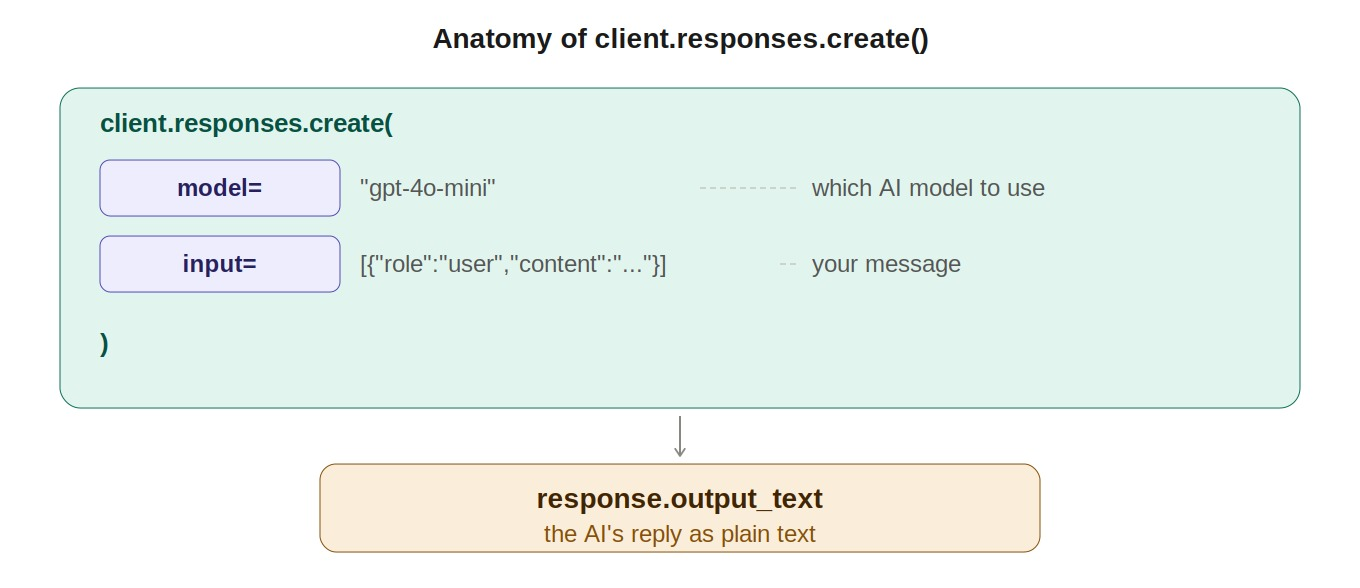

In [ ]:
# This sends your first message to the AI and prints the reply.
#
# Breaking it down:
#   client.responses.create()  →  the function that does the sending
#   model=                     →  which AI to use (gpt-4o-mini is fast and affordable)
#   input=                     →  your message, wrapped in a list
#   {"role": "user", ...}      →  "user" means this message is from you
#   response.output_text       →  the AI's reply as plain text

response = client.responses.create(
    model="gpt-4o-mini",
    input=[
        {"role": "user", "content": "What is machine learning? Explain it in two sentences."}
    ]
)

print(response.output_text)

### What just happened?

You sent a message to the same AI that powers ChatGPT, and read the reply — entirely in code. The website you usually use is just a polished wrapper around this same process.

---
## Part 3 — Trying Different Messages

The only thing you need to change is the text inside the quotes. Everything else stays the same.

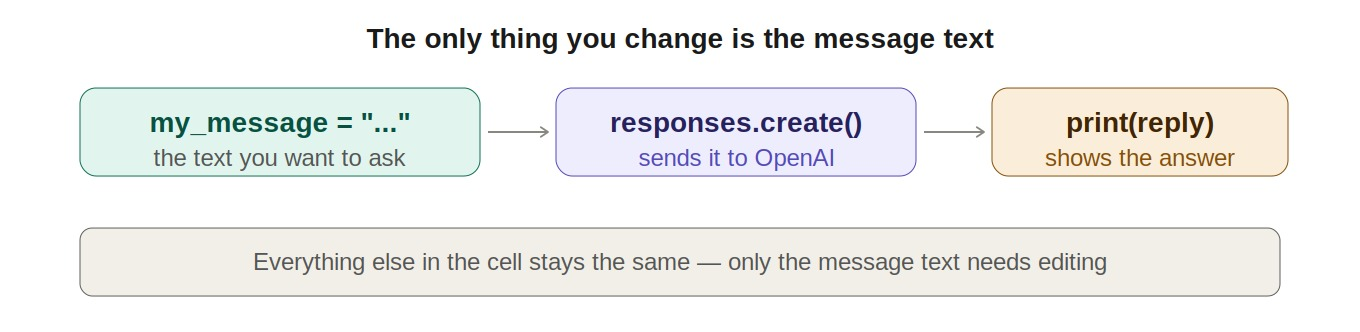

In [ ]:
# ✏️ Change the message below to anything you like, then run the cell.
# Try something you would normally type into ChatGPT.

my_message = "Explain supply and demand in simple terms, using a coffee shop as an example."

response = client.responses.create(
    model="gpt-4o-mini",
    input=[
        {"role": "user", "content": my_message}
    ]
)

print(response.output_text)

In [ ]:
# ✏️ Try a question relevant to your own studies or work.

my_message = "What are three things a business should consider before adopting AI?"

response = client.responses.create(
    model="gpt-4o-mini",
    input=[
        {"role": "user", "content": my_message}
    ]
)

print(response.output_text)

---
## Part 4 — The `instructions` Parameter
### Giving the Model a Role Before It Answers

In ChatGPT you may have seen "custom instructions" or "system prompts" — a way to tell the model who it should be before the conversation starts.

In the Responses API this is the `instructions=` parameter. You pass it a string describing the persona, tone, and rules you want the model to follow.

Think of it as a briefing you give a staff member before they take a customer call.

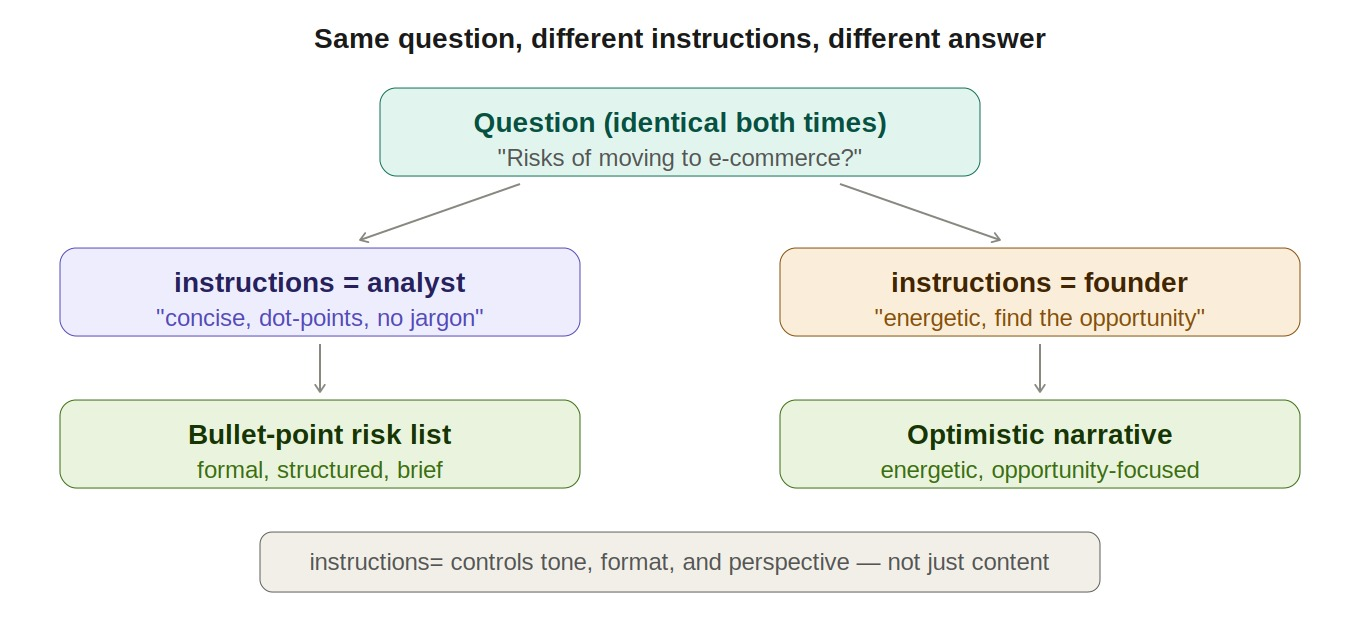

In [ ]:
# The instructions= parameter sets the model's persona for this call.
# Notice how the same question gets a completely different style of answer
# depending on what instructions you give.

# Persona 1: concise analyst
response = client.responses.create(
    model="gpt-4o-mini",
    instructions="You are a concise business analyst. Always respond in dot-point format. Use plain language — no jargon.",
    input=[
        {"role": "user", "content": "What are the risks of a small retailer moving to e-commerce?"}
    ]
)

print("── Analyst persona ──")
print(response.output_text)

In [ ]:
# Persona 2: enthusiastic founder — same question, very different answer
response = client.responses.create(
    model="gpt-4o-mini",
    instructions="You are an enthusiastic startup founder. Use energetic, optimistic language and always find the opportunity in every challenge.",
    input=[
        {"role": "user", "content": "What are the risks of a small retailer moving to e-commerce?"}
    ]
)

print("── Founder persona ──")
print(response.output_text)

### Pause and notice

You sent the **exact same question** twice and got two completely different answers — because the instructions changed the model's perspective.

This is one of the most useful things you can do with the API: control the voice, format, and role of the model in your own code.

---
## Part 5 — Making It Reusable
### Wrapping the API Call in a Function

So far each cell repeats the same pattern. In real code you wrap repeated patterns in a **function** — a named block of code you can call with different inputs without retyping everything.

This is the step that turns a notebook experiment into something practical.

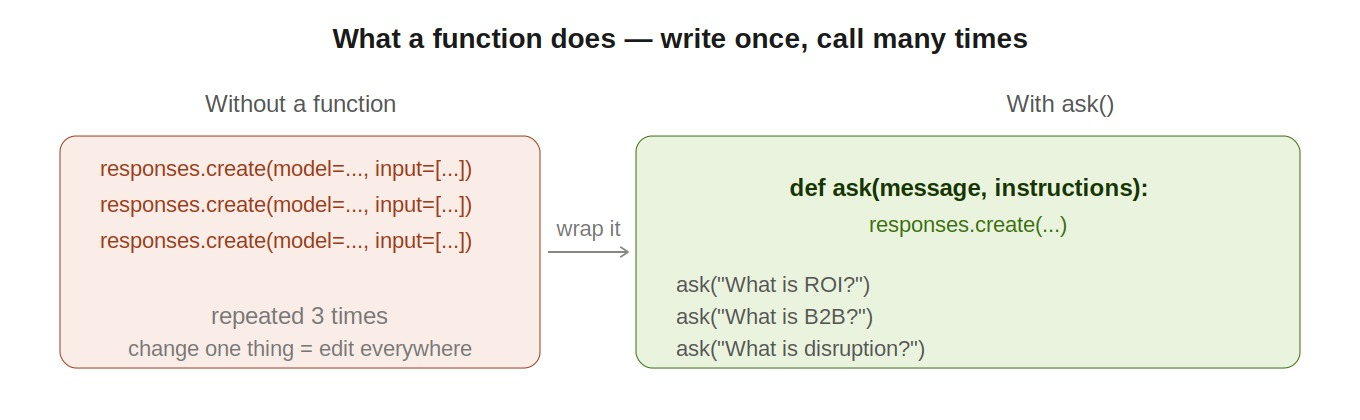

In [ ]:
# A function is defined once with "def", then called by name whenever you need it.
# This one takes a message (required) and instructions (optional),
# sends them to the API, and returns the reply as a string.

def ask(message: str, instructions: str = None) -> str:
    """Send a message to the API and return the reply as text."""

    # Build the request — start with the required fields
    kwargs = {
        "model": "gpt-4o-mini",
        "input": [{"role": "user", "content": message}]
    }

    # Only add instructions if one was provided
    if instructions:
        kwargs["instructions"] = instructions

    # Send the request and return just the text
    response = client.responses.create(**kwargs)
    return response.output_text


# Test it — calling the function is now just one line
reply = ask("What does ROI stand for and what does it measure?")
print(reply)

In [ ]:
# Now calling the API for multiple questions is clean and readable.
# No repeated boilerplate — just the questions.

questions = [
    "What is a value proposition?",
    "What is the difference between B2B and B2C?",
    "What does 'disruptive innovation' mean?",
]

for q in questions:
    print(f"Q: {q}")
    print(f"A: {ask(q)}")
    print("-" * 60)

---
## Part 6 — What Else Is in the Response?

`response.output_text` is the shortcut to the text answer. But the full `response` object contains more — including the model name and how many tokens were used.

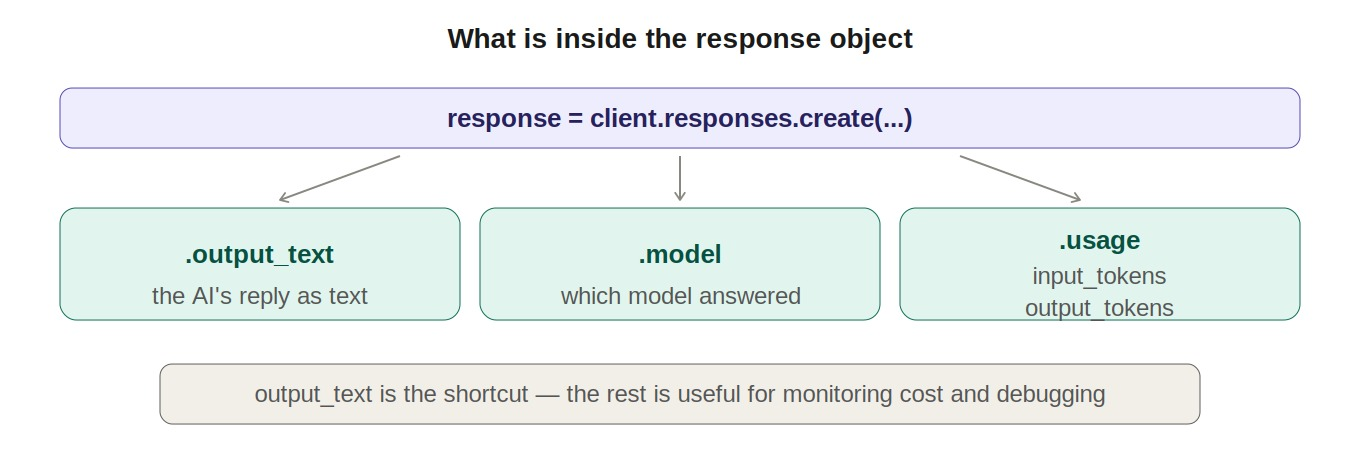

In [ ]:
# Let's inspect the full response object, not just the text.

response = client.responses.create(
    model="gpt-4o-mini",
    input=[{"role": "user", "content": "Name three programming languages in one sentence."}]
)

print("=== The answer ===")
print(response.output_text)

print("\n=== Which model answered ===")
print(response.model)

print("\n=== Token usage ===")
# Tokens are the unit OpenAI uses to measure and charge for text.
# Roughly: 1 token ≈ ¾ of a word
print(f"  Tokens in your message : {response.usage.input_tokens}")
print(f"  Tokens in the reply    : {response.usage.output_tokens}")
print(f"  Total tokens this call : {response.usage.total_tokens}")

### What is a token?

OpenAI charges per **token**, not per word or character. A token is roughly ¾ of a word on average.

- `"Hello, how are you?"` ≈ 5 tokens
- A 500-word essay ≈ 650 tokens
- `gpt-4o-mini` costs a fraction of a cent per 1,000 tokens

Everything you run in this entire notebook costs well under $0.01 of API credit.

---
## Part 7 — A Multi-Turn Conversation
### How the API Handles Memory

ChatGPT remembers what you said earlier in a conversation. When you write code, **you are responsible for keeping that history yourself** — the API does not remember anything between calls unless you send the previous messages each time.

This surprises most people. The API is stateless — every call starts fresh unless you pass the history in.

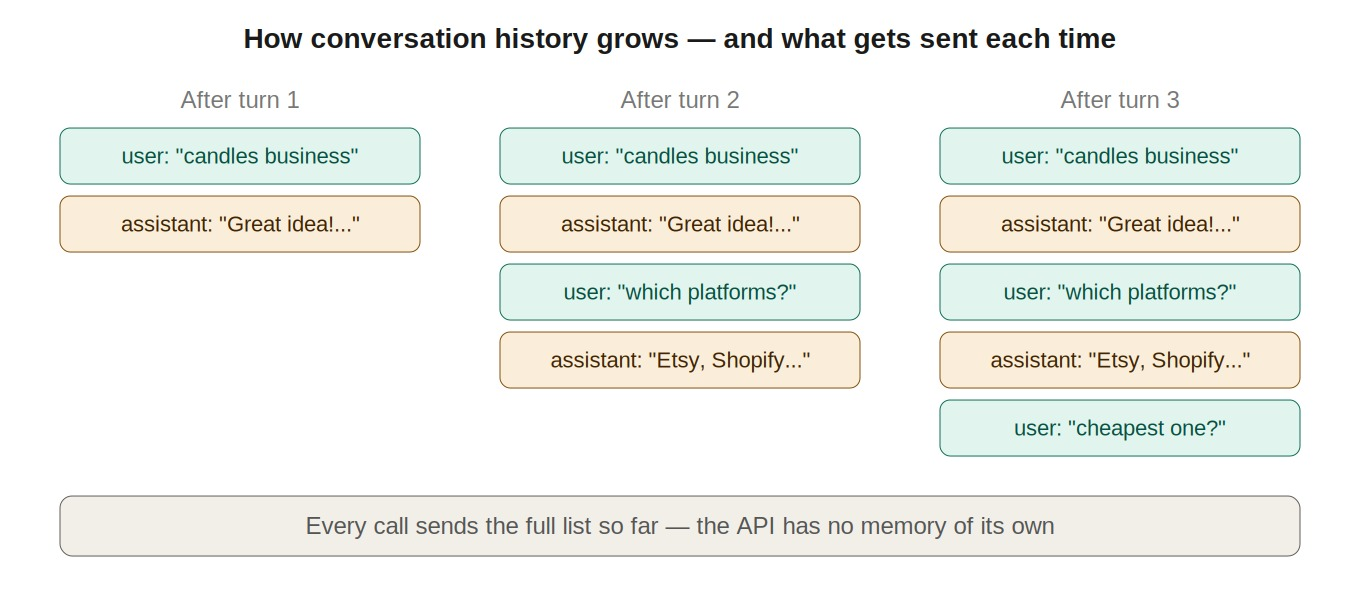

In [ ]:
# We maintain a "conversation" list and add each message to it.
# Every time we call the API we send the full list — so the model
# can see everything that was said before.
# This is exactly what the ChatGPT website does behind the scenes.

conversation = []   # starts empty — no history yet

def chat(user_message: str) -> str:
    """Send a message as part of an ongoing conversation."""

    # Add the new message to the running history
    conversation.append({"role": "user", "content": user_message})

    # Send the entire history to the API
    response = client.responses.create(
        model="gpt-4o-mini",
        input=conversation       # ← the full list, not just this message
    )

    reply = response.output_text

    # Add the model's reply to history too, so the next call sees it
    conversation.append({"role": "assistant", "content": reply})

    return reply


# Turn 1
print("You:", "I'm thinking about starting a small online business selling handmade candles.")
print("AI: ", chat("I'm thinking about starting a small online business selling handmade candles."))
print()

# Turn 2 — no need to repeat the context; it's already in the history
print("You:", "What platforms would you recommend for selling them?")
print("AI: ", chat("What platforms would you recommend for selling them?"))
print()

# Turn 3
print("You:", "Which of those is cheapest to get started with?")
print("AI: ", chat("Which of those is cheapest to get started with?"))

In [ ]:
# Let's print the conversation list so you can see exactly
# what gets sent to the API on each call.
# The ChatGPT website builds this same structure — you just never see it.

print("Conversation history (what gets sent to the API):")
print()
for msg in conversation:
    role = msg["role"].upper()
    # Trim long messages for readability
    preview = msg["content"][:120] + ("..." if len(msg["content"]) > 120 else "")
    print(f"[{role}]")
    print(f"  {preview}")
    print()

### The key point

Every time you send a turn, you resend the **entire history**. The model has no memory of its own — it only knows what is in the list you pass in.

This is why:
- Long conversations cost more (more tokens each turn)
- ChatGPT sometimes forgets very old messages (there is a limit to how much history fits)
- You can start completely fresh just by setting `conversation = []`

---
## Part 8 — Putting It Together
### A Practical Business Assistant

Let's finish by building something you could actually use: a function that produces a structured business brief on any topic you give it.

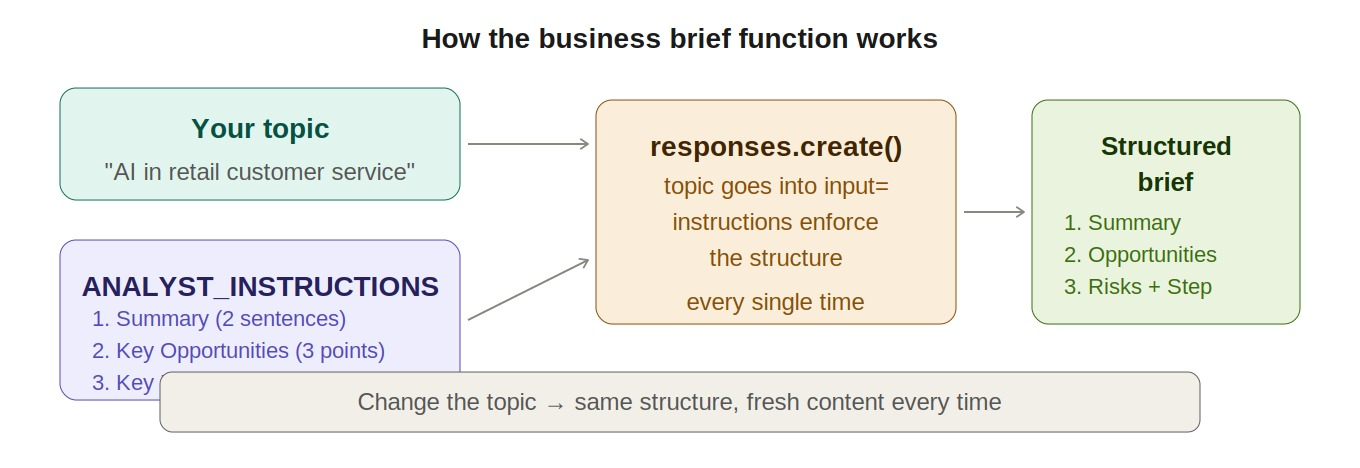

In [ ]:
# The instructions enforce a specific output format every time.
# The model follows the structure reliably because we ask it to
# explicitly in the instructions string.

ANALYST_INSTRUCTIONS = """
You are a concise business analyst preparing executive briefings.
Always structure your response exactly as follows:
1. Summary (2 sentences max)
2. Key Opportunities (3 dot points)
3. Key Risks (3 dot points)
4. Recommended First Step (1 sentence)
Use plain language. Be specific, not generic.
"""

def business_brief(topic: str) -> str:
    """Generate a structured business brief on any topic."""
    return ask(f"Prepare a business brief on: {topic}", instructions=ANALYST_INSTRUCTIONS)


# Try it
topic = "using AI chatbots for customer service in a retail business"
print(f"Topic: {topic}")
print("=" * 60)
print(business_brief(topic))

In [ ]:
# ✏️ Change my_topic to anything relevant to you and run this cell.

my_topic = "launching a subscription box service for local produce"   # ← change this

print(f"Topic: {my_topic}")
print("=" * 60)
print(business_brief(my_topic))

---
## What You Learned

| Concept | What it means |
|---------|--------------|
| **API** | A way for your code to talk to an external service like OpenAI |
| **API key** | Your code's password — keep it private |
| **`client.responses.create()`** | The function that sends a message and gets a reply |
| **`input=`** | Your message(s) — the same as what you type in ChatGPT |
| **`instructions=`** | The model's persona and rules before it answers |
| **`output_text`** | The model's reply as plain text |
| **Tokens** | The unit OpenAI charges by — roughly ¾ of a word each |
| **Conversation history** | A list of messages you maintain; the API has no memory of its own |
| **Function** | A named, reusable block of code — the `ask()` function is a good example |

---
## Try These Yourself

**Task 1:** Change `my_message` in Part 3 to a question from your own field. Run it.

**Task 2:** Write an `instructions` string that makes the model respond like a specific business professional — a CFO, a marketing director, or a startup founder. Test it with the same question using three different personas.

**Task 3:** Add a fourth turn to the conversation in Part 7. Ask something that only makes sense if the model remembers the earlier context. Does it?

**Task 4:** Modify the `business_brief` function to also include a "Competitor Landscape" section. Update `ANALYST_INSTRUCTIONS` and test it.

**Task 5 (stretch):** Add `print(f"Tokens used: {response.usage.total_tokens}")` inside the `ask()` function. Run a few queries and watch how the count changes with longer and shorter prompts.

---
## Resources

- [OpenAI Responses API Reference](https://platform.openai.com/docs/api-reference/responses)
- [OpenAI Pricing](https://openai.com/api/pricing/) — see exactly what tokens cost
- [OpenAI Playground](https://platform.openai.com/playground) — a visual interface that shows you the API structure
- [OpenAI API Keys](https://platform.openai.com/api-keys) — create and manage your keys
- [OpenAI Cookbook](https://cookbook.openai.com/) — practical code examples